# Challenge TelecomX - Análisis de evasión de clientes

Este proyecto tiene como objetivo analizar los datos de clientes de TelecomX
para identificar factores relacionados con la evasión de clientes (Churn).

Para ello se realizará:

- Extracción de datos desde el repositorio
- Transformación y limpieza del dataset
- Análisis exploratorio de datos
- Elaboración de conclusiones

Las herramientas utilizadas serán Python, Pandas y Matplotlib.

# **# 1: Extracción de datos**

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
## Cargar dataset##

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

In [49]:
## Ver datos ##

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [50]:
## Ver estructura ##

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


# **# 2:Transformación de datos**

In [51]:
## Expandir JSON ##

customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account = pd.json_normalize(df["account"])

In [52]:
## Crear dataset final ##

df_final = pd.concat([
    df[['customerID','Churn']],
    customer,
    phone,
    internet,
    account
], axis=1)

In [53]:
## Revisar datos ##

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [54]:
## Revisar valores nulos ##

df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [55]:
## Convertir columnas numéricas ##

df_final["Charges.Total"] = pd.to_numeric(df_final["Charges.Total"], errors="coerce")

In [56]:
## Eliminar nulos ##

df_final = df_final.dropna()

# **# 3 : Carga y análisis**

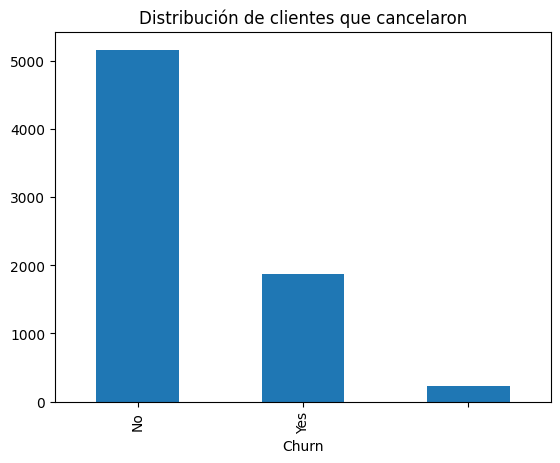

In [57]:
## Distribución del churn ##

df_final["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de clientes que cancelaron")

plt.show()

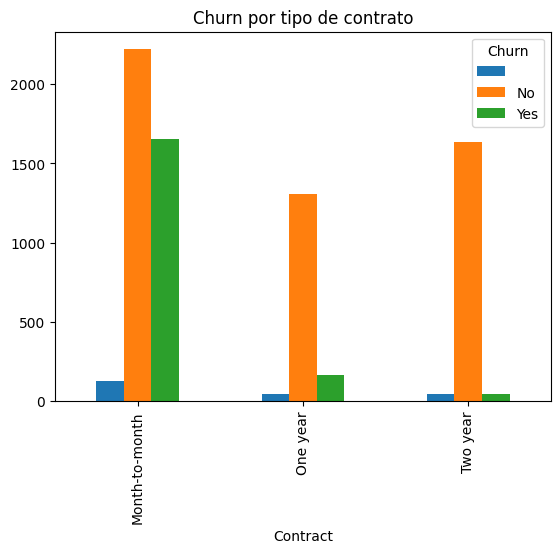

In [58]:
## Churn por tipo de contrato ##

df_final.groupby(["Contract","Churn"]).size().unstack().plot(kind="bar")

plt.title("Churn por tipo de contrato")

plt.show()

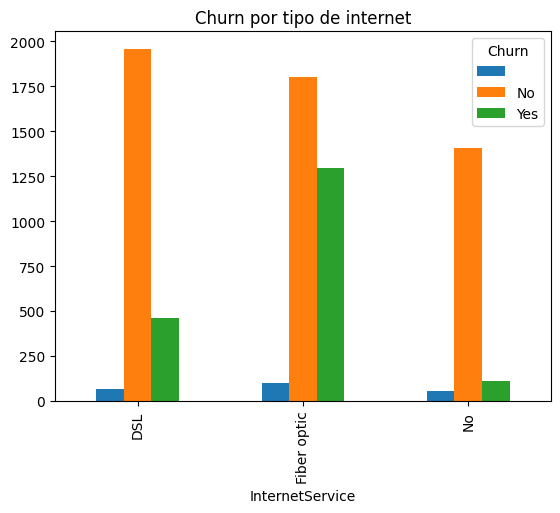

In [59]:
## Churn por servicio de internet ##

df_final.groupby(["InternetService","Churn"]).size().unstack().plot(kind="bar")

plt.title("Churn por tipo de internet")

plt.show()

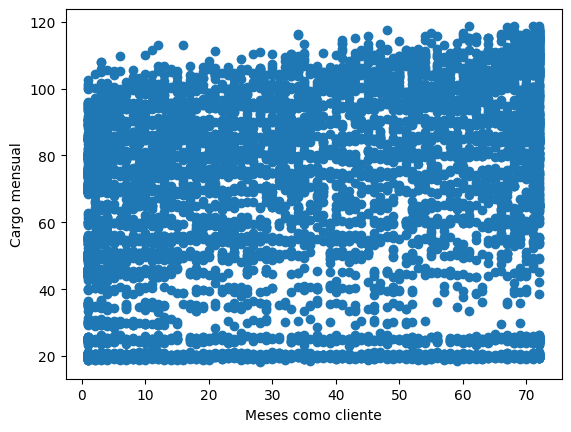

In [60]:
## Relación cargos vs tiempo ##

plt.scatter(df_final["tenure"], df_final["Charges.Monthly"])

plt.xlabel("Meses como cliente")
plt.ylabel("Cargo mensual")

plt.show()

### **4: EXTRA - ANÁLISIS DE CORRELACIÓN**

# Análisis de correlación (Extra)

Como paso adicional se explorará la correlación entre variables numéricas
del dataset para identificar posibles factores asociados con la evasión
de clientes (Churn).

Se analizarán relaciones como:

- La relación entre la cuenta diaria y la evasión.
- La relación entre la cantidad de servicios contratados y el churn.

Este análisis puede ayudar a identificar variables importantes
para futuros modelos predictivos.

In [61]:
## Crear la variable "Cuenta diaria" ##

df_final["Cuenta_Diaria"] = df_final["Charges.Monthly"] / 30

df_final[["Charges.Monthly","Cuenta_Diaria"]].head()

,Charges.Monthly,Cuenta_Diaria
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [62]:
## Cantidad de servicios contratados ##

servicios = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_final["Cantidad_Servicios"] = df_final[servicios].apply(lambda x: (x=="Yes").sum(), axis=1)

df_final[["Cantidad_Servicios"]].head()

,Cantidad_Servicios
0,4
1,3
2,2
3,5
4,3


In [63]:
## Matriz de correlación ##

corr = df_final.corr(numeric_only=True)

corr

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuenta_Diaria,Cantidad_Servicios
SeniorCitizen,1.000000,0.017333,0.220098,0.103499,0.220098,0.097071
tenure,0.017333,1.000000,0.246981,0.825118,0.246981,0.524671
Charges.Monthly,0.220098,0.246981,1.000000,0.652109,1.000000,0.802755
Charges.Total,0.103499,0.825118,0.652109,1.000000,0.652109,0.798140
Cuenta_Diaria,0.220098,0.246981,1.000000,0.652109,1.000000,0.802755
Cantidad_Servicios,0.097071,0.524671,0.802755,0.798140,0.802755,1.000000


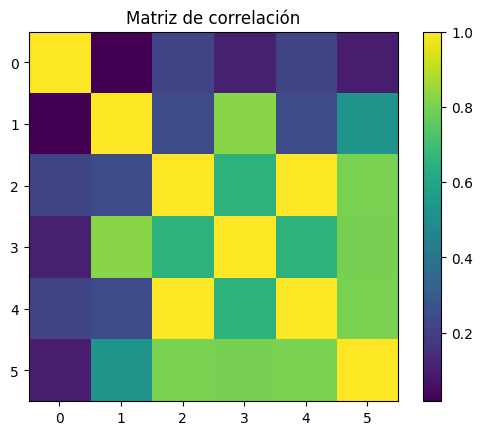

In [64]:
## Gráfico de correlación ##

import matplotlib.pyplot as plt

plt.imshow(corr)

plt.colorbar()

plt.title("Matriz de correlación")

plt.show()

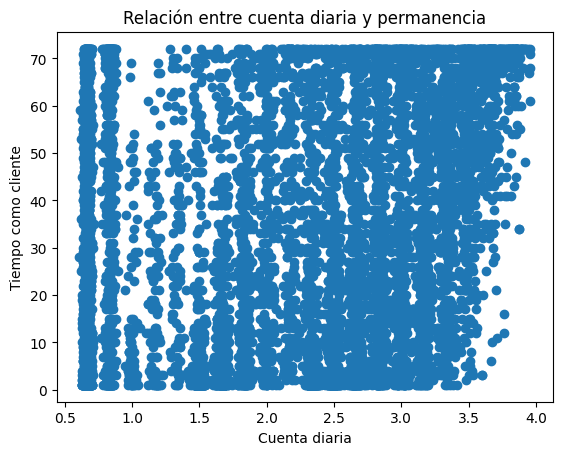

In [65]:
## Gráfico de dispersión ##

plt.scatter(df_final["Cuenta_Diaria"], df_final["tenure"])

plt.xlabel("Cuenta diaria")

plt.ylabel("Tiempo como cliente")

plt.title("Relación entre cuenta diaria y permanencia")

plt.show()

# Informe Final – Análisis de evasión de clientes en TelecomX

## Introducción

En este proyecto se realizó un análisis exploratorio de datos con el objetivo de comprender mejor el problema de evasión de clientes (churn) en la empresa TelecomX. La compañía enfrenta una alta tasa de cancelación de servicios, lo que representa un problema importante para el negocio, ya que la pérdida constante de clientes puede afectar los ingresos y la estabilidad de la empresa.

Para abordar este problema, se trabajó con un dataset que contiene información de los clientes, los servicios que tienen contratados, sus métodos de pago, el tiempo que llevan como clientes y los cargos asociados a sus servicios. Utilizando herramientas de análisis de datos en Python, se realizó un proceso de limpieza, transformación y exploración de los datos para identificar posibles patrones relacionados con la cancelación de servicios.

---

## Preparación y limpieza de datos

Antes de comenzar el análisis fue necesario preparar el dataset. Los datos originales estaban en formato JSON y contenían algunas columnas anidadas, por lo que primero se separaron estas estructuras para poder trabajar con ellas de manera más clara en un solo conjunto de datos.

Después de organizar las columnas, se revisaron los tipos de datos para asegurarse de que las variables numéricas estuvieran correctamente definidas. También se verificó la existencia de valores nulos y registros duplicados. En algunos casos fue necesario convertir columnas a formato numérico y eliminar valores faltantes para evitar errores durante el análisis.

Este proceso fue importante porque garantiza que el análisis posterior se realice con datos consistentes y confiables.

---

## Análisis exploratorio de datos

Una vez que el dataset estuvo limpio y organizado, se procedió a realizar un análisis exploratorio para entender mejor el comportamiento de los clientes.

Uno de los primeros análisis fue observar la distribución de clientes que cancelaron el servicio frente a los que permanecen activos. Este análisis permitió confirmar que existe una cantidad considerable de clientes que han decidido abandonar la empresa.

Posteriormente se analizaron algunas variables que podrían estar relacionadas con este comportamiento.

### Tipo de contrato

Uno de los factores más relevantes que se observaron fue el tipo de contrato. Los resultados muestran que los clientes con contratos mensuales presentan una mayor probabilidad de cancelar el servicio en comparación con aquellos que tienen contratos de uno o dos años. Esto sugiere que los contratos a largo plazo generan mayor estabilidad en la base de clientes.

### Servicios contratados

También se analizó la relación entre los servicios que tiene contratado el cliente y la probabilidad de churn. Se observó que algunos clientes con menos servicios adicionales tienden a cancelar con mayor frecuencia. Esto podría indicar que los clientes que utilizan más servicios dentro de la empresa tienen una mayor fidelidad.

### Cargos mensuales y tiempo como cliente

Otro análisis importante fue la relación entre los cargos mensuales y el tiempo que los clientes llevan utilizando el servicio. En algunos casos se observó que clientes con cargos mensuales relativamente altos y poco tiempo en la empresa tienen mayor tendencia a cancelar el servicio.

Este comportamiento podría indicar que algunos clientes no perciben suficiente valor en el servicio en relación con el precio que están pagando.

---

## Análisis adicional de correlación

Como parte del análisis adicional se exploró la correlación entre diferentes variables numéricas del dataset. Este tipo de análisis permite identificar relaciones entre variables que podrían ser útiles para futuros modelos predictivos.

Se creó una variable adicional llamada **cuenta diaria**, que representa aproximadamente cuánto paga un cliente por día en función de su cargo mensual. También se analizó la cantidad de servicios que cada cliente tiene contratados.

A través de gráficos de dispersión y matrices de correlación se pudieron observar algunas relaciones interesantes entre el tiempo como cliente, los cargos mensuales y el total pagado. Aunque las correlaciones no son extremadamente fuertes, sí permiten identificar algunas tendencias que podrían explorarse más a fondo en modelos de predicción de churn.

---

## Conclusiones

Después de realizar el análisis exploratorio del dataset, se pudieron identificar algunos factores que parecen estar relacionados con la evasión de clientes.

Uno de los factores más claros es el tipo de contrato. Los clientes con contratos mensuales muestran una mayor tendencia a cancelar el servicio, mientras que los contratos de mayor duración parecen ayudar a retener clientes.

También se observó que los clientes con menos servicios adicionales o con cargos mensuales más altos podrían tener mayor probabilidad de abandonar la empresa, especialmente si llevan poco tiempo utilizando el servicio.

Estos resultados sugieren que TelecomX podría considerar estrategias como incentivar contratos de mayor duración, ofrecer beneficios adicionales o paquetes de servicios, y mejorar la percepción de valor para los clientes nuevos.

---

## Consideraciones finales

Este análisis corresponde a una primera etapa de exploración de datos. Los resultados obtenidos ayudan a entender mejor el comportamiento de los clientes, pero también abren la puerta a análisis más avanzados.

En el futuro se podrían desarrollar modelos de machine learning que permitan predecir con mayor precisión qué clientes tienen mayor probabilidad de cancelar el servicio. Esto permitiría a la empresa tomar acciones preventivas para reducir la tasa de churn y mejorar la retención de clientes.
